# Heart Disease

> This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease. 

[Source]('https://www.kaggle.com/johnsmith88/heart-disease-dataset')

A heart attack (Cardiovascular diseases) occurs when the flow of blood to the heart muscle suddenly becomes blocked. Cardiovascular disease is the leading cause of death in the U.S. It’s important to learn about your heart to help prevent it. If you have it, you can live a healthier, more active life by learning about your disease and taking care of yourself.

Heart atta condition manifested by diseased blood vessels, structural problems, and blood clots.


What you are going to find in this notebook?


✅ **Data QA**

- Dimensional analysis 
- Data type
- Nulls values
- Duplicated values
- Inconsistences
- Outliers
- Data QA conclusions

📊 **Reporting**

- Bivariate analysis
- Feature engineering
- Reporting conclusions

🤖 **Machine Learning**

- Develop a "competition" betwen differents classification models
- Evaluate results
- Select the best and train it
- Models conclusions

**Plase if you consider usefull pleas help me uptvoting my work.**
### Imports

In [1]:
import pandas as pd
import numpy as np
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns


#Models
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

#Oculto los warnings 
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

**Constants**

In [2]:
rcParams['xtick.labelsize'] = 16
rcParams['figure.figsize'] = (11.7,8.27)

**Load dataset**

In [3]:
df = pd.read_csv('./app/in/heart.csv')

### Data QA
**Head of Dataset**

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


**Dimensional analysis**

In [5]:
df.shape

(1025, 14)

**Data Type**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


**NULLS values**

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

**Duplicated values**

In [8]:
df.duplicated().sum()

723

**Inconsistences to be chequed**

- Negative ages
- Negative values of blood pressure at rest
- Negative serum cholesterol values in mg/dl
- Negative max heart rate achieved vsalues
- Negative oldpeak values

In [9]:
continuous_features = ['age',
                      'trestbps',
                      'chol',
                      'thalach',
                      'oldpeak'
                     ]
for feature in continuous_features:
    print(str(feature)+': '+str(sum(df[feature] < 0)))


age: 0
trestbps: 0
chol: 0
thalach: 0
oldpeak: 0


**Outliers**

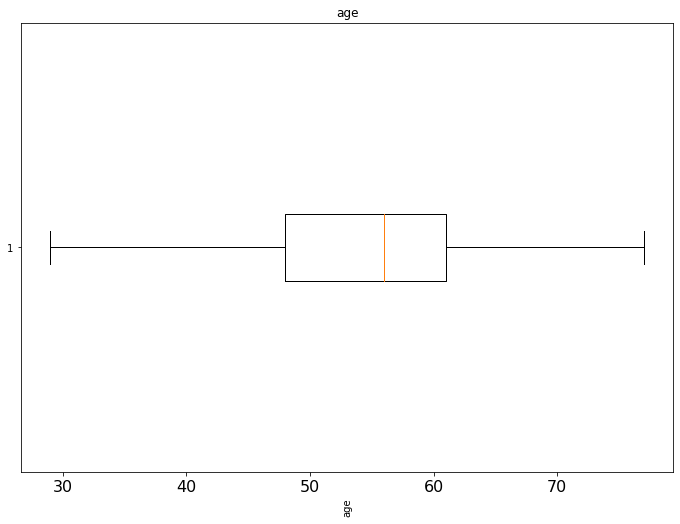

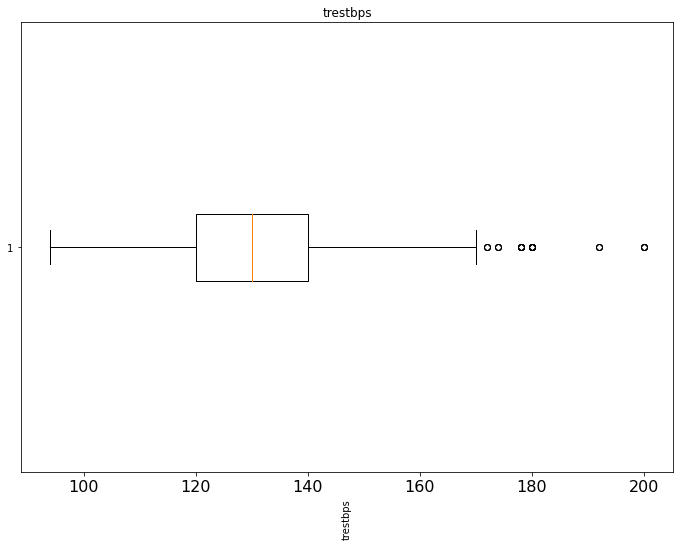

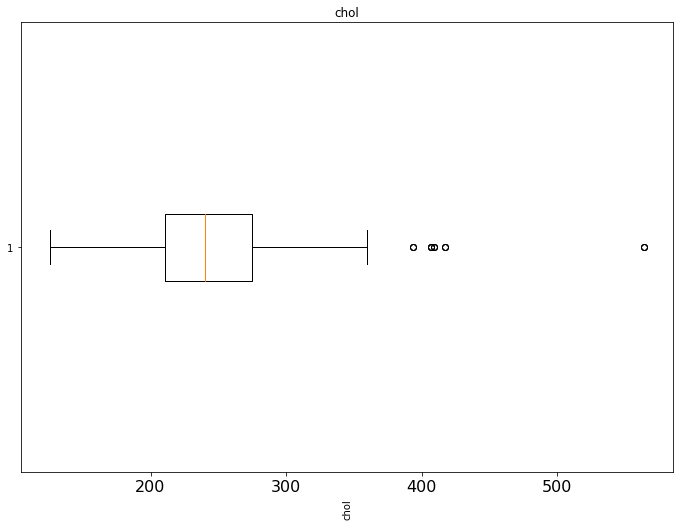

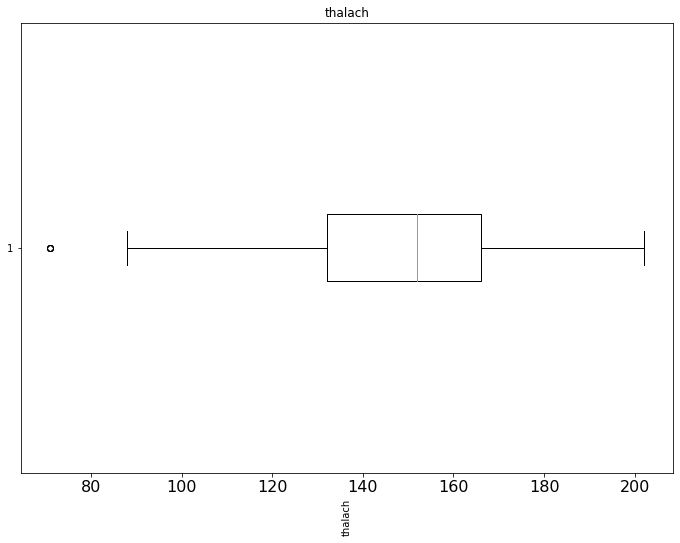

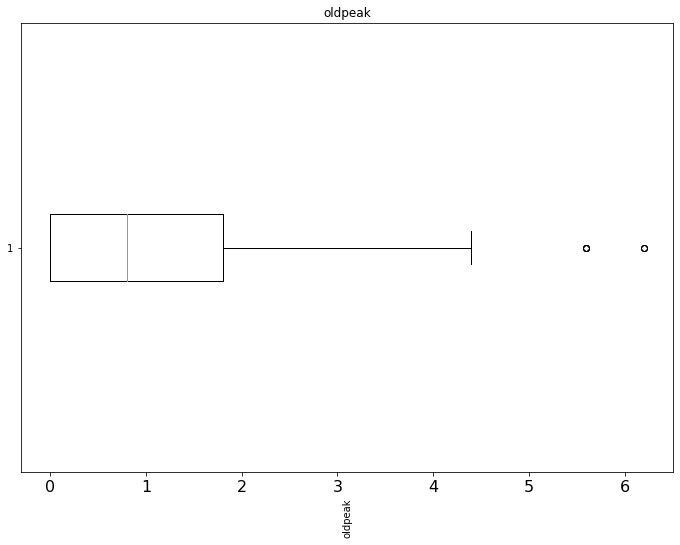

In [10]:
for cf in continuous_features:
    plt.boxplot(df[cf], vert=False)
    plt.title(cf)
    plt.xlabel(xlabel = cf,
               rotation=90)

    plt.show();

**Data QA conclusions**
- Dataset has 0 NULL values
- Dataset has 0 duplicated values
- Dataset has 0 relevant inconsistences
- Dataset has a few outliers. In case this features has lot of relevance with the target, some feature engineering is goint to be done.

### Reporting
**Bivariate analysis**

The graph below show the correlation between all numerical features.

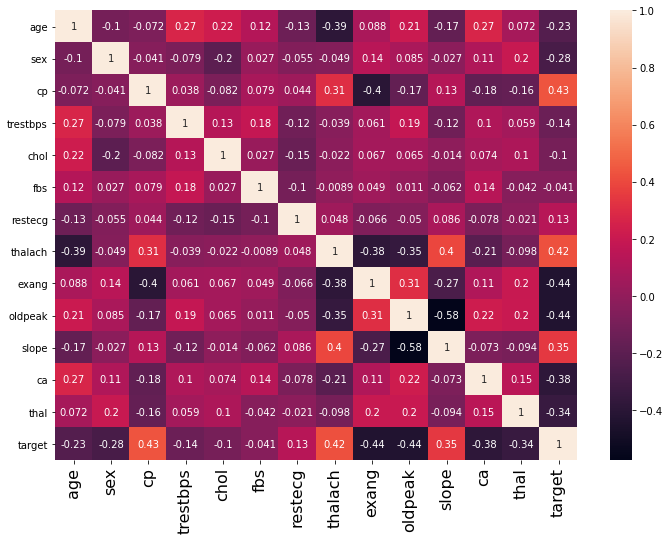

In [11]:
sns.heatmap(df.corr(),
            annot=True);

**Feature engineering**

- age will be grouped into 4 groups divided by age quearters

In [12]:
window_age = (df['age'].max() - df['age'].min())/4
df['enc_age'] = df['age'].apply(lambda x: 0 if df.loc[x,'age'] < df['age'].min()+(window_age)\
                                else 1 if df.loc[x,'age'] < df['age'].min()+(2*window_age)\
                                else 2 if df.loc[x,'age'] < df['age'].max()-(window_age)\
                                else 3)

df = df.drop(columns=['age'], axis=1)

In [13]:
df.groupby(by=['enc_age'])['enc_age'].count()/len(df['enc_age'])

enc_age
0    0.122927
1    0.209756
2    0.483902
3    0.183415
Name: enc_age, dtype: float64

**Reporting conclusions**
- The top 3 feature which has a higher relation with the target are: 
    - cp: 0.43
    - thalac: 0.42 
    - slope: 0.35
- Making some feature engineering at age taht don't improve to much the correlation.

### Reporting

Split data set into train-test 

In [14]:
y = df["target"]
X = df[['cp','restecg','thalach','slope','enc_age']] #Solo selecciono los que tienen coeficiente de correlación mayor a 0.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Competitor canditates

In [15]:
modelos=[{"name":"LogisticRegression", "model":LogisticRegression()},
         {"name":"KNeighborsClassifier", "model":KNeighborsClassifier()},
         {"name":"DecisionTreeClassifier", "model":DecisionTreeClassifier()},
         {"name":"RandomForestClassifier", "model":RandomForestClassifier()},
         {"name":"SVC", "function":SVC()}
        ]

**Competition**

In [16]:
best_params = []

for i in range(len(modelos)):
    if modelos[i].get('name') == 'LogisticRegression':
        parametros={'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
                    'C': [100, 10, 1.0, 0.1, 0.01]}
        
        grid_search = GridSearchCV(modelos[i].get('model'), param_grid=parametros)
        grid_search.fit(X_train, y_train)
        best_params.append({
            'name':modelos[i].get('name'),
            'model': modelos[i].get('model'),
            'best_params':grid_search.best_params_,
            'best_score':grid_search.best_score_
        })
    elif modelos[i].get('name') == 'KNeighborsClassifier':
        
        parametros={'algorithm':['auto', 'ball_tree', 'kd_tree', 'brute'],
                    'n_neighbors':[5,6,8,9,10,12,15,20]}
        
        grid_search = GridSearchCV(modelos[i].get('model'), param_grid=parametros)
        grid_search.fit(X_train, y_train)
        best_params.append({
            'name':modelos[i].get('name'),
            'model': modelos[i].get('model'),
            'best_params':grid_search.best_params_,
            'best_score':grid_search.best_score_
        })
        
    elif modelos[i].get('name') == 'DecisionTreeClassifier':
        
        parametros= {'criterion':['gini', 'entropy'], #Se cambiaron los parametros
                    'splitter':['best', 'random']}
        
        grid_search = GridSearchCV(modelos[i].get('model'), param_grid=parametros)
        grid_search.fit(X_train, y_train)
        best_params.append({
            'name':modelos[i].get('name'),
            'model': modelos[i].get('model'),
            'best_params':grid_search.best_params_,
            'best_score':grid_search.best_score_
        })
    
    elif modelos[i].get('name') == 'RandomForestClassifier':
        
        parametros= {'criterion':['gini', 'entropy'],
                      'n_estimators':[1,5,10,20,50]}
        
        grid_search = GridSearchCV(modelos[i].get('model'), param_grid=parametros)
        grid_search.fit(X_train, y_train)
        best_params.append({
            'name':modelos[i].get('name'),
            'model': modelos[i].get('model'),
            'best_params':grid_search.best_params_,
            'best_score':grid_search.best_score_
        })

**Results**

In [17]:
best_scores = pd.DataFrame(best_params).sort_values(by='best_score', ascending=False).reset_index(drop=True)
best_scores

,name,model,best_params,best_score
0,DecisionTreeClassifier,DecisionTreeClassifier(),"{'criterion': 'gini', 'splitter': 'random'}",0.965854
1,RandomForestClassifier,RandomForestClassifier(),"{'criterion': 'gini', 'n_estimators': 50}",0.953659
2,KNeighborsClassifier,KNeighborsClassifier(),"{'algorithm': 'brute', 'n_neighbors': 5}",0.782927
3,LogisticRegression,LogisticRegression(),"{'C': 0.01, 'solver': 'liblinear'}",0.753659


**Train the model and make predictions**

In [18]:
model = best_scores.loc[0,'model']
params = best_scores.loc[0,'best_params']

skLearn_model = model.set_params(**params)
model_fit = skLearn_model.fit(X_train, y_train)

model_predictions_train = model_fit.predict(X_train)
model_predictions_test = model_fit.predict(X_test)

joblib.dump(model_fit, './app/models/DecisionTreeClassifier.pkl')

['./app/models/DecisionTreeClassifier.pkl']

**Metrics**

In [19]:
model_fit.score(X_test,y_test)

0.9853658536585366

In [20]:
print(classification_report(y_train, model_predictions_train))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       401
           1       1.00      0.98      0.99       419

    accuracy                           0.99       820
   macro avg       0.99      0.99      0.99       820
weighted avg       0.99      0.99      0.99       820



**Feature importance**

In [21]:
importance = model_fit.feature_importances_

In [22]:
data = {
    'Features': X_train.columns,
    'Importance': importance
}
pd.DataFrame(data).sort_values(by='Importance', ascending = False)

,Features,Importance
2,thalach,0.474558
0,cp,0.313137
4,enc_age,0.106524
3,slope,0.087215
1,restecg,0.018566


**Conclusions**
- DecisionTreeClassifier is the model selected because of its metrics.
- Metrics in train and test are awesome.
- thalach is the feature which has more wigh in this model.

**Export best model**

In [23]:
joblib.dump(model_fit, './app/models/DecisionTreeClassifier.pkl')

['./app/models/DecisionTreeClassifier.pkl']